# Difference-in-Differences in Practice

**Course**: Quantitative Econometrics  
**Topic**: Practical DiD with multiple time periods  
**Application**: Minimum legal drinking age and youth traffic fatalities

This notebook is designed to be teachable in class. The goal is not only to estimate a coefficient, but to make the comparison problem transparent.

## Learning goals

1. Load and inspect a state-year policy panel.
2. Construct a credible DiD outcome and treatment indicator.
3. Estimate a two-way fixed-effects DiD regression.
4. Estimate and plot an event-study specification.
5. Read the results economically rather than mechanically.

## Setup

This notebook uses the `Fatalities` dataset from the **AER** package. If you place `Fatalities.csv` or `AER_Fatalities.csv` in `lectures/code/data/`, the notebook will read the local file first. Otherwise it falls back to `statsmodels.get_rdataset`.

The helper module `panel_policy_lab.py` lives in the same folder as this notebook.

In [2]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

candidate_dirs = [Path.cwd(), Path.cwd() / "lectures" / "code"]
for candidate in candidate_dirs:
    if (candidate / "panel_policy_lab.py").exists():
        sys.path.insert(0, str(candidate))
        break

import panel_policy_lab as lab

lab.set_plot_style()
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## Load the panel and inspect the design

The policy variable here is whether a state has a minimum legal drinking age of 21. The outcome is a fatality rate for the 18-20 age group.

This is a useful classroom example because:

- it is a genuine policy panel,
- treatment timing varies across states,
- the time dimension is comfortably larger than five periods,
- it naturally leads to both TWFE DiD and event-study discussions.

In [3]:
panel = lab.prepare_fatalities_panel()

summary_df = pd.DataFrame(
    {
        "Statistic": [
            "Number of observations",
            "Number of states",
            "First year",
            "Last year",
            "States ever treated"
        ],
        "Value": [
            len(panel),
            panel["state"].nunique(),
            panel["year"].min(),
            panel["year"].max(),
            int(panel.groupby("state")["ever_treated"].max().sum())
        ]
    }
)

display(summary_df)
display(panel.head())

,Statistic,Value
0,Number of observations,336
1,Number of states,48
2,First year,1982
3,Last year,1988
4,States ever treated,47


,state,year,spirits,unemp,income,emppop,beertax,baptist,mormon,drinkage,...,pop2124,milestot,unempus,emppopus,gsp,fatal_rate_1820,mlda21,adopt_year,ever_treated,event_time
0,al,1982,1.370,14.400,"10,544.152",50.692,1.539,30.356,0.328,19.000,...,"290,000.062","28,516.000",9.700,57.800,-0.022,44.684,0,"1,986.000",True,-4.000
1,al,1983,1.360,13.700,"10,732.798",52.147,1.789,30.334,0.343,19.000,...,"290,000.156","31,032.000",9.600,57.900,0.047,49.287,0,"1,986.000",True,-3.000
2,al,1984,1.320,11.100,"11,108.791",54.168,1.714,30.312,0.359,19.000,...,"288,000.156","32,961.000",7.500,59.500,0.063,47.526,0,"1,986.000",True,-2.000
3,al,1985,1.280,8.900,"11,332.627",55.271,1.653,30.289,0.376,19.670,...,"284,000.312","35,091.000",7.200,60.100,0.027,46.653,0,"1,986.000",True,-1.000
4,al,1986,1.230,9.800,"11,661.507",56.514,1.610,30.267,0.393,21.000,...,"263,000.281","36,259.000",7.000,60.700,0.032,56.604,1,"1,986.000",True,0.000


## First look: raw group means

A good DiD workflow starts with pictures, not regression output. The figure below compares average youth fatality rates in states that currently have MLDA = 21 and states that do not.

This is not yet the causal estimate. It is just the raw comparison structure.

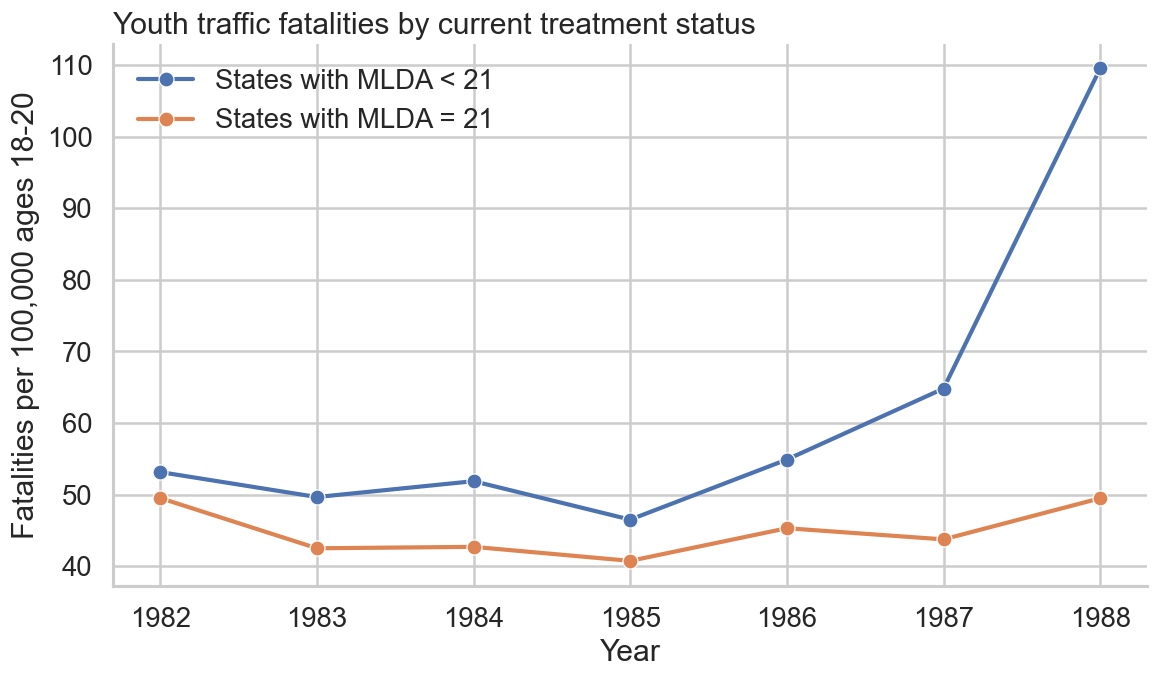

In [5]:
lab.plot_did_group_means(panel)

## Two-way fixed-effects DiD

We now estimate a standard TWFE DiD specification:

$$
fatal\_rate_{st} = \alpha_s + \lambda_t + \delta \cdot MLDA21_{st} + u_{st}.
$$

The coefficient of interest is $\delta$. Standard errors are clustered at the state level.

In [6]:
twfe = lab.twfe_did(panel)

coef_table = pd.DataFrame(
    {
        "term": twfe.params.index,
        "estimate": twfe.params.values,
        "std_error": twfe.bse.values,
        "t_stat": twfe.tvalues.values,
        "p_value": twfe.pvalues.values,
    }
)

display(coef_table.loc[coef_table["term"] == "mlda21"].reset_index(drop=True))

,term,estimate,std_error,t_stat,p_value
0,mlda21,-2.198,1.994,-1.102,0.270


### Interpretation prompt

Do not stop at significance. Ask:

1. What is the unit of the outcome?  
2. Is the estimated effect economically large?  
3. Is this a clean average treatment effect, or a weighted average coming from staggered timing?  
4. What comparison is TWFE actually making in this panel?

## Event study

Because treatment timing varies across states, an event-study plot is helpful. It lets us inspect two things:

- whether pre-treatment coefficients are already drifting away from zero,
- whether the post-treatment effect appears immediate or gradual.

We use event time $-1$ as the omitted reference period.

,term,event_time,estimate,std_error,ci_low,ci_high
0,lead_4,-4,1.493,3.490,-5.347,8.333
1,lead_3,-3,0.376,2.876,-5.262,6.013
2,lead_2,-2,1.002,2.602,-4.098,6.101
3,lag_0,0,-2.934,2.256,-7.355,1.487
4,lag_1,1,0.318,1.497,-2.616,3.252
5,lag_2,2,-0.933,2.095,-5.041,3.174
6,lag_3,3,-0.239,2.021,-4.199,3.722
7,lag_4,4,0.814,2.228,-3.553,5.182


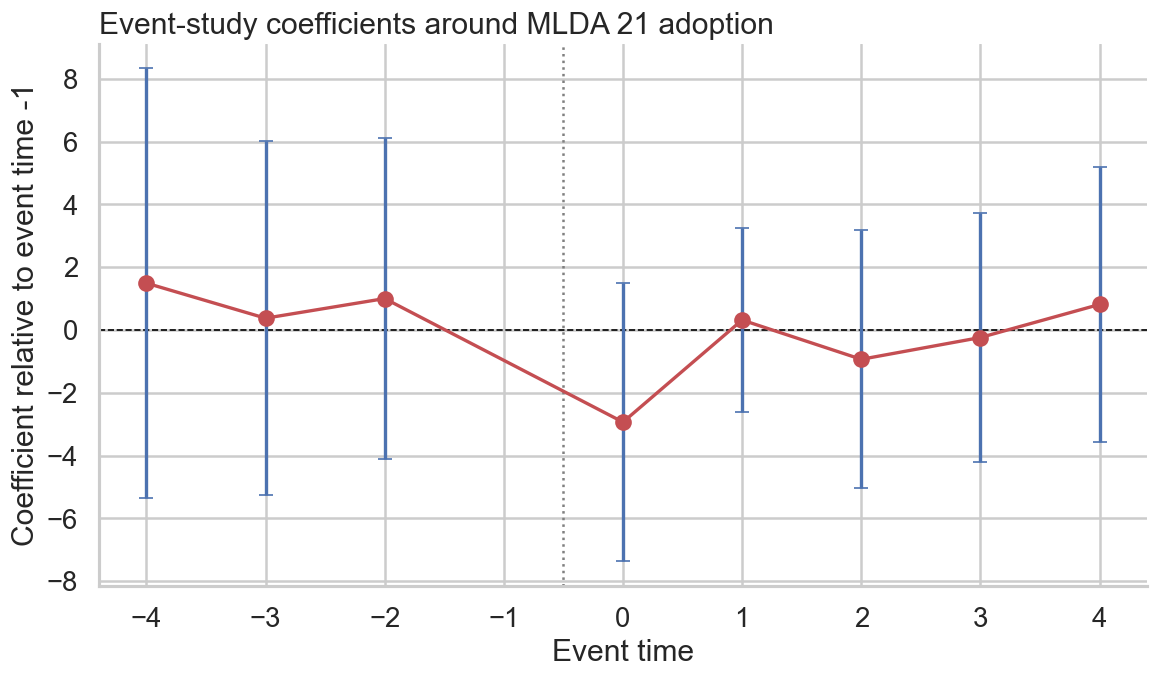

In [7]:
event_results = lab.event_study_did(panel, leads=4, lags=4)
display(event_results)
lab.plot_event_study(event_results)


## Suggested extensions

1. Add controls such as beer taxes or vehicle miles traveled, then compare the MLDA estimate.  
2. Restrict the sample to a narrower time window and see how the estimate moves.  
3. Try a version with state-specific linear trends and discuss what is gained and lost.  
4. Compare the raw group-means plot with the event-study plot and explain why they answer different questions.